In [1]:
# 20260311 - this is the cleaned notebook for blog post https://paul.mou.dev/posts/2026-03-10-flow

In [2]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Dataloaders

In [3]:
from PIL import Image
from torchvision import transforms
import io
import torch

# Suppose `image_bytes` contains your image as bytes
# e.g., image_bytes = open("image.jpg", "rb").read()

def load_img_bytes(img_bytes, resize=False):
    # 1. Load image from bytes using PIL
    image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
    
    # 2. Transform the image to a tensor
    transform = transforms.Compose([
        transforms.Resize((64, 64)) if resize else transforms.Lambda(lambda x: x),
        # HWC to CHW
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # → [-1,1]
    ])
    image_tensor = transform(image)
    return image_tensor

In [4]:
import pathlib as pl
import glob
import io
import random
from functools import lru_cache

import pyarrow.parquet as pq
import numpy as np
from tqdm import tqdm

C_ROOT = pl.Path("/media/2nvme/data/CelebA-faces-with-attributes")
C_ROOT2 = pl.Path("/media/2nvme/data/celeba-hq-256x256")

class CelebWithConditionals(Dataset):
    def __init__(self, split="train", sm=False):
        self.sm = sm
        glob_pattern = glob.glob(str(C_ROOT2) + "/data/" + split + "*.parquet")
        
        dfs = []
        dfs_len = []
        total = 0
        for f in tqdm(glob_pattern):
            try:
                p = pq.ParquetFile(f)
                sp = SimpleParquetWrapper(p)
                
                total += sp.total
                
                dfs_len.append(total)
                dfs.append(sp)
            except:
                print('failed', f)

        self.total = total
        self.dfs_len = dfs_len
        self.dfs = dfs
        
        assert len(self.dfs_len) == len(self.dfs)
        
    def __len__(self):
        # TODO: fix me
        return self.total

    def __getitem(self, idx):
        dfs_idx = next(r for r, size in enumerate(self.dfs_len) if idx < size)

        if dfs_idx - 1 >= 0:
            idx = idx - self.dfs_len[dfs_idx - 1]
            
        df = self.dfs[dfs_idx]
        item = df[idx]
        return item

    def rows(self):
        for i in range(self.total):
            yield self.__getitem(i)

    def __getitem__(self, idx):
        idx = idx % self.total
        dfs_idx = next(r for r, size in enumerate(self.dfs_len) if idx < size)

        if dfs_idx > 0:
            idx = idx - self.dfs_len[dfs_idx-1]
            
        df = self.dfs[dfs_idx]
        item = df[idx]

        # wav, sr = self.load_wav(idx, item, full=False)
        
        return {
            "img": load_img_bytes(item['image']['bytes'], resize=self.sm),
            "attrs": self._get_attrs(item),
        }

    def _get_attrs(self, item):
        res = []
        for k in item.keys()[3:]:
            res.append(item[k])
        attrs = torch.tensor(res)
        return attrs
        

class SimpleParquetWrapper:
    def __init__(self, p):
        self.p = p

        total = 0
        row_grp_size = []
        for row_grp in range(p.num_row_groups):
            total += p.metadata.row_group(row_grp).num_rows
            row_grp_size.append(total)
            
        self.row_grp_size = row_grp_size
        self.total = total

    @lru_cache(maxsize=20)
    def _get_row_grp(self, row_group_idx):
        row_group = self.p.read_row_group(row_group_idx)
        # Read the data from the row group
        table = row_group.to_pandas()
        return table

    def __getitem__(self, i):
        # Check if the row index i is valid
        if i >= self.total or i < 0:
            raise IndexError(f"Row index {i} out of bounds, total rows: {self.total}")
        
        # Find the row group and row within the row group for index i
        row_group_idx = next(r for r, size in enumerate(self.row_grp_size) if i < size)
        # Read the specific row group
        table = self._get_row_grp(row_group_idx)
        
        # Calculate the relative index within the selected row group
        if row_group_idx > 0:
            row_within_group = i - self.row_grp_size[row_group_idx - 1]
        else:
            row_within_group = i
        
        # Extract the specific row from the table (convert to pandas for easy access)
        row = table.iloc[row_within_group]
        return row

B = 32

cc = CelebWithConditionals()
item = next(iter(cc))
img_tensor = item['img']
img_tensor.shape

dataloader = DataLoader(
    cc,
    batch_size=B,
    num_workers=10,
    drop_last=True,
    pin_memory=True,
    # TODO: we need to support shuffling!!!
    shuffle=False,
)

100%|█████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 7373.52it/s]


# Model 

In [5]:
def get_proper_2d_coords_norm(H, W, patch_size, stride, device='cuda'):
    # Calculate how many patches unfold actually creates
    num_h = (H - patch_size) // stride + 1
    num_w = (W - patch_size) // stride + 1
    
    # The first patch center is at p/2, each subsequent is +stride
    mid = patch_size / 2
    y_centers = torch.arange(num_h, device=device) * stride + mid
    # print(y_centers)
    x_centers = torch.arange(num_w, device=device) * stride + mid
    # print(x_centers)
    
    # Normalize to [-1, 1] for better Transformer stability
    # This keeps (0,0) at the center of the image
    y_coords = (y_centers / H) * 2 - 1
    x_coords = (x_centers / W) * 2 - 1
    
    grid_y, grid_x = torch.meshgrid(y_coords, x_coords, indexing='ij')
    
    # Flatten to match (B, Tokens, 2)
    # result: (num_h * num_w, 2)
    return torch.stack([grid_x, grid_y], dim=-1).reshape(-1, 2)

In [6]:
class RotaryPositionalEmbedding(nn.Module):
    def __init__(self, dim, base=10_000):
        super().__init__()
        self.dim = dim
        self.base = base
        
        # Only store the inverse frequency - compute cos/sin dynamically
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
    
    def forward(self, x, t=None):
        """
        x: tensor of shape (batch, seq_len, num_heads, head_dim)
        Returns: rotated tensor of same shape
        """
        device = x.device
        dtype = x.dtype
            
        if t is None:
            seq_len = x.size(1)
            # Compute positions dynamically - only for current sequence length
            t = torch.arange(seq_len, device=device, dtype=dtype)
        if t.dim() == 2:
            assert t.shape[0] == 1
            t = t.squeeze(0)
            
        freqs = torch.outer(t, self.inv_freq.to(dtype))
        
        # Compute cos and sin
        cos = torch.cos(freqs)  # (seq_len, dim//2)
        sin = torch.sin(freqs)  # (seq_len, dim//2)
        
        return self.apply_rotary_emb(x, cos, sin)
    
    def apply_rotary_emb(self, x, cos, sin):
        # x: (B, T, C)
        
        # half half version
        x1, x2 = x.chunk(2, dim=-1)

        # cos: (1, T, C//2)
        cos = cos[None, :, :]
        # sin: (1, T, C//2)
        sin = sin[None, :, :]
        
        # Apply rotation
        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x1 * sin + x2 * cos
        
        # Recombine
        rotated_x = torch.cat([rotated_x1, rotated_x2], dim=-1)
        return rotated_x
        
    def apply_rotary_emb_original(self, x, cos, sin):
        # interleaved version
        # x: (B, T, C)
        # x1: (B, T, C//2)
        # x2: (B, T, C//2)
        x1, x2 = x[..., ::2], x[..., 1::2]

        # cos: (1, T, C//2)
        cos = cos[None, :, :]
        # sin: (1, T, C//2)
        sin = sin[None, :, :]
        
        # Apply rotation
        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x1 * sin + x2 * cos
        
        # Recombine
        rotated_x = torch.stack([rotated_x1, rotated_x2], dim=-1)
        return rotated_x.flatten(start_dim=-2)

class RoPE2D(nn.Module):
    def __init__(self, dim, base=20_000):
        super().__init__()
        assert dim % 4 == 0, "dim must be divisible by 4 for 2D RoPE"
        
        self.dim = dim
        self.base = base
        
        # Split frequencies between height and width dimensions
        self.rope = RotaryPositionalEmbedding(dim // 2, base=base)
    
    def forward(self, x, pos_2d):
        B, T, C = x.shape
        assert C == self.dim
        
        # Extract positions
        pos_h = pos_2d[..., 0]  # (..., seq_len)
        pos_w = pos_2d[..., 1]  # (..., seq_len)

        x1, x2 = x.chunk(2, dim=-1)

        # (B, T, C//2)
        xh = self.rope(x1, pos_h)
        xw = self.rope(x2, pos_w)
        
        return torch.cat([xh, xw], dim=-1)

In [7]:
class SwiGLU(nn.Module):
    def __init__(self, dim, hidden_dim=None, bias=False):
        super().__init__()
        self.w12 = nn.Linear(dim, 2 * hidden_dim, bias=bias)
        self.w3 = nn.Linear(hidden_dim, dim, bias=bias)

    def forward(self, x):
        # x: (B, S, dim)
        x12 = self.w12(x)                                    # (B, S, 2*hidden_dim)
        x, gate = x12.chunk(2, dim=-1)                       # split into value and gate
        x = x * F.silu(gate)                                 # SwiGLU activation
        x = self.w3(x)                                       # (B, S, dim)
        return x

In [8]:
class Derf(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.alpha = nn.Parameter(torch.ones(dim)) # Scale
        self.shift = nn.Parameter(torch.zeros(dim)) # Pointwise bias

    def forward(self, x):
        # erf is a pointwise operation natively supported in PyTorch
        return torch.erf(self.alpha * x + self.shift)

In [9]:
class Head(nn.Module):
    def __init__(self, in_feature, out_feature, ctx_len, causal=True, qk_norm=True, rope_2d=False, derf=True):
        super().__init__()
        
        self.k = nn.Linear(in_feature, out_feature, bias=False)
        self.q = nn.Linear(in_feature, out_feature, bias=False)
        self.v = nn.Linear(in_feature, out_feature, bias=False)
        
        self.qnorm = Derf(out_feature) if derf and qk_norm else nn.RMSNorm(out_feature) if qk_norm else None
        self.knorm = Derf(out_feature) if derf and qk_norm else nn.RMSNorm(out_feature) if qk_norm else None

        if rope_2d:
            self.rope = RoPE2D(out_feature)
        else:
            self.rope = RotaryPositionalEmbedding(out_feature)
        
        self.causal = causal

        self.register_buffer('tril', torch.tril(torch.ones(ctx_len, ctx_len)))
        
        nn.init.kaiming_uniform_(self.k.weight)
        nn.init.kaiming_uniform_(self.q.weight)
        nn.init.kaiming_uniform_(self.v.weight)

    def forward(self, xs, *, k=None, q=None, v=None, pos_2d=None):
        # xs: (B, T, C)
        B, T, C = xs.shape
        
        # k: (B, T, out_feature)
        k = self.k(xs if k is None else k)
        # q: (B, T, out_feature)
        q = self.q(xs if q is None else q)
        # k: (B, T, out_feature)
        v = self.v(xs if v is None else v)

        q_before = q
        k_before = k

        if self.qnorm is not None:
            q = self.qnorm(q)
            k = self.knorm(k)
        
        if pos_2d is not None:
            q = self.rope(q, pos_2d.unsqueeze(0))
            k = self.rope(k, pos_2d.unsqueeze(0))
        else:
            q = self.rope(q)
            k = self.rope(k)
            
        '''
        logger.debug(
            self._kname + f"::Q norm before RoPE:{q.shape} {torch.norm(q_before):.2e}, after RoPE: {torch.norm(q):.2e}")
        logger.debug(
            self._kname + f"::K norm before RoPE:{k.shape} {torch.norm(k_before):.2e}, after RoPE: {torch.norm(k):.2e}")
        '''
        
        # (B, T, C') @ (B, C', T) => (B, T, T)
        wei = q @ k.transpose(-2, -1) * (q.shape[-1] ** -0.5)

        # causal mask
        # print('tril.shape', self.tril.shape)
        # print('wei.shape', wei.shape)
        if self.causal:
            wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
            
        wei = wei.softmax(-1)
        # logger.debug(self._kname + f"::max attn: {wei.max().item():.4f}, Entropy: {-(wei * wei.log()).sum(dim=-1).mean().item():.4f}")
        
        out = wei @ v
        return out # , k, q, v

class MultiHead(nn.Module):
    def __init__(self, n_head, in_feature, out_feature, ctx_len, *, causal=True, rope_2d=False):
        super().__init__()
        self.n_heads = nn.ModuleList([
            Head(in_feature, out_feature, ctx_len, causal=causal, rope_2d=rope_2d)
            for _ in range(n_head)
        ])
        self.proj = nn.Linear(out_feature * n_head, out_feature * n_head) 
        
    def forward(self, xs, **kwargs):
        # xs: (B, T, C)
        n_outs = []
        
        for h in self.n_heads:
            n_outs.append(h(xs, **kwargs))

        out = torch.cat(n_outs, dim=-1)
        out = self.proj(out)
        return out

class TemporalEmbedding(nn.Module):
    def __init__(self, embed_dim, max_len=100):
        super().__init__()
        self.embed_dim = embed_dim
        self.max_len = max_len
        self.register_buffer('freqs', 
                             torch.arange(1, embed_dim // 2 + 1) * torch.pi)
    def forward(self, t):
        emb = self.freqs * t[..., None] / self.max_len
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

import torch
import torch.nn as nn

class ImprovedTemporalEmbedding(nn.Module):
    def __init__(self, embed_dim, base=10000, scale=1000):
        super().__init__()
        self.embed_dim = embed_dim
        self.scale = scale # Critical for t in [0, 1]
        
        # Half dimension for sin and cos
        half_dim = embed_dim // 2
        
        # Standard geometric frequencies
        inv_freq = 1.0 / (base ** (torch.arange(0, half_dim).float() / half_dim))
        self.register_buffer("inv_freq", inv_freq)
        
        # MLP Projection: Swish/SiLU is the gold standard here
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.SiLU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, t):
        # Ensure t is (Batch,)
        if t.ndim == 0: t = t.unsqueeze(0)
        
        # 1. Scale t to a larger range (e.g., 0 to 1000)
        # 2. Compute frequencies: (Batch, 1) * (1, half_dim)
        freqs = (t.float() * self.scale)[:, None] * self.inv_freq[None, :]
        
        # 3. Cat sin and cos for a rich harmonic representation
        emb = torch.cat((freqs.sin(), freqs.cos()), dim=-1)
        
        # 4. Project into the manifold space
        return self.mlp(emb)
        
class TransformerBlock(nn.Module):
    def __init__(self, chan, n_head, ctx_len, *, causal=True, rope_2d=False, derf=True):
        super().__init__()
        
        self.n1 = Derf(chan) if derf else nn.LayerNorm(chan)
        self.n2 = Derf(chan) if derf else nn.LayerNorm(chan)
        
        self.mlp = SwiGLU(chan, chan * 4)
        self.attn = MultiHead(n_head, chan, chan // n_head, ctx_len, causal=causal, rope_2d=rope_2d)

    def forward(self, x, **kwargs):
        # x: (B, T, C)
        x = x + self.attn(self.n1(x), **kwargs)
        x = x + self.mlp(self.n2(x))
        return x

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Vit(nn.Module):
    def __init__(self, hidden_dim, n_head, p=16, n_blocks=12, rope_2d=False, H=256, W=256):
        super().__init__()
        self.p = p
        self.rope_2d = rope_2d
        
        # 1. Generate 2D Window (Hann Window)
        # This reduces edge importance and smooths transitions
        w1d = torch.hann_window(p, periodic=False)
        w2d = w1d.view(p, 1) @ w1d.view(1, p)
        
        # w2d = torch.ones((p, p))
        self.register_buffer('patch_window', w2d) # (p, p)

        # Embeddings and Projections
        self.t_embed = ImprovedTemporalEmbedding(64)
        self.init_proj = nn.Linear(64 + 3 * p ** 2, hidden_dim, bias=False)
        
        self.blks = nn.ModuleList([
            TransformerBlock(hidden_dim, n_head, 1024, rope_2d=rope_2d, causal=False) 
            for _ in range(n_blocks)
        ])
        self.final_proj = nn.Linear(hidden_dim, 3 * p ** 2, bias=False)

        # Pre-calculate Geometry Buffers
        self.resolutions = [H, 64] 
        self.strides = [p, p // 4 * 3] 
        
        for res in self.resolutions:
            for s in self.strides:
                suffix = f"{res}_s{s}"
                
                # Create Windowed Overlap Mask
                # Instead of ones, we unfold/fold the window itself
                ones_win = self.patch_window.view(1, 1, p, p).expand(1, 3, p, p)
                # We need to simulate the unfold/fold of a full image of windows
                dummy_img = torch.zeros(1, 3, res, res)
                # Calculate how many patches we have
                num_h = (res - p) // s + 1
                num_w = (res - p) // s + 1
                
                # Replicate the window across all patch positions
                windows = self.patch_window.view(1, p*p, 1).expand(1, p*p, num_h * num_w)
                # Fold the windows to see the cumulative denominator
                # We do this for one channel and expand to 3 for memory efficiency
                win_denom = F.fold(windows, output_size=(res, res), kernel_size=p, stride=s)
                # Avoid division by zero
                win_denom = torch.clamp(win_denom, min=1e-8)
                
                self.register_buffer(f"overlap_{suffix}", win_denom)
                
                if self.rope_2d:
                    pos = get_proper_2d_coords_norm(res, res, p, s)
                    self.register_buffer(f"pos2d_{suffix}", pos)

    def forward(self, xs, ts, use_half_stride=False):
        B, C, H, W = xs.shape
        stride = (self.p // 4 * 3) if use_half_stride else self.p
        
        suffix = f"{H}_s{stride}"
        overlap_mask = getattr(self, f"overlap_{suffix}")
        pos_2d = getattr(self, f"pos2d_{suffix}") if self.rope_2d else None

        # 1. Patchify
        unf = F.unfold(xs, kernel_size=self.p, stride=stride)
        unf = unf.permute(0, 2, 1) # (B, Tokens, C*p*p)

        # 2. Temporal Embedding
        t_emb = self.t_embed(ts).unsqueeze(1).repeat(1, unf.shape[1], 1)

        # 3. Transformer Processing
        hs = self.init_proj(torch.cat([unf, t_emb], dim=-1))
        
        kwargs = {'pos_2d': pos_2d} if self.rope_2d else {}
        for blk in self.blks:
            hs = blk(hs, **kwargs) # + hs

        # 4. Final Projection
        # hs: (B, Tokens, C*p*p)
        hs = self.final_proj(hs) 
        
        # 5. Apply Windowing to Predicted Patches
        # Reshape to apply window spatially: (B, Tokens, C, p, p)
        B, T, _ = hs.shape
        hs = hs.view(B, T, C, self.p, self.p)
        hs = hs * self.patch_window.view(1, 1, 1, self.p, self.p)
        
        # 6. Fold and Normalize
        # Fold expects (B, C*p*p, Tokens)
        hs = hs.reshape(B, T, -1).permute(0, 2, 1)
        combined = F.fold(hs, output_size=(H, W), kernel_size=self.p, stride=stride)
        
        # The overlap_mask now contains the sum of windows at each pixel
        return combined / overlap_mask

# Training Loop 

In [11]:
import torch
import torch.nn.functional as F
import numpy as np

def sample_logit_t(dim, resolution=256, base_res=256, sig=0.8, mu_base=-0.8):
    """
    Adjusts the logit-normal sampling mean based on resolution.
    Shifts the distribution to higher noise for higher resolutions.
    """
    # 1. Calculate the resolution shift (from Simple Diffusion paper)
    # As resolution increases, we shift the mean to sample higher noise levels
    mu = mu_base - math.log(resolution/base_res)
    
    # 2. Sample from logit-normal distribution
    u_sample = torch.randn(dim) * sig + mu
    t = torch.sigmoid(u_sample)
    
    return t

In [12]:
vit = Vit(768, 12, n_blocks=12, rope_2d=True).cuda()

In [13]:
# Vit loop
from collections import defaultdict
from tqdm import tqdm

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

print('vit', count_parameters(vit) / 1e6, "M")

losses = []
other_losses = defaultdict(list)
mean_losses = []
other_mean_losses = defaultdict(list)

use_amp = True

def run(epochs=1):
    global vit, dataloader
    
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    vit.cuda().train()
    
    all_params = [*vit.parameters()]
    
    lr = 1e-4
    optimizer = torch.optim.AdamW(
        all_params,
        betas=(0.9, 0.95),
        lr=lr,
        weight_decay=0)
    
    i = 0
    status_prefix = ""
    for epoch in tqdm(range(epochs)):
        for data in dataloader: 
            img = data["img"].cuda() 
            B, C, H, W = img.shape

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(dtype=torch.float16, enabled=use_amp):
                # with te.fp8_autocast(enabled=use_fp8):
                # NOTE: t@1 means no noise, t@0 means pure noise
                t = sample_logit_t((B,1))[:, None, None].cuda()
                
                z = ((1 - t)) * torch.randn_like(img) + (t) * img 
                v = (img - z) / (1 - t)

                x_pred = vit(z, t.squeeze(-1).squeeze(-1).squeeze(-1), use_half_stride=True)
                v_pred = (x_pred - z) / (1 - t)
                 
                loss = (v - v_pred) ** 2 
                loss = loss.mean() 
                
                recon_loss = (img - x_pred).mean()
                other_losses['recon_loss'].append(recon_loss.detach().item())
                    
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(vit.parameters(), 1)
            scaler.step(optimizer)

            # Updates the scale for next iteration.
            scaler.update()

            i += 1 
            losses.append(loss.detach().item())

            if i % (100) == 0:
                mean_losses.append(np.mean(losses[-100:]))
                
                if status_prefix:
                    output = [status_prefix]
                else:
                    output = [f"{i}:{mean_losses[-1]:.4f}"]
                
                for k, v in other_losses.items():
                    other_mean = np.mean(v[-100:])
                    
                    other_mean_losses[k].append(other_mean)
                    output.append(f"{k}:{other_mean:.4f}")
                
                print(",".join(output))
                status_prefix = ""
                

vit 114.59104 M


In [14]:
print("xready")

xready


In [15]:
run(100)

/tmp/ipykernel_6493/2815845954.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float16, enabled=use_amp):


100:0.5029,recon_loss:-0.0089
200:0.2156,recon_loss:-0.0016
300:0.1688,recon_loss:-0.0028
400:0.1432,recon_loss:-0.0023
500:0.1357,recon_loss:-0.0027
600:0.1221,recon_loss:-0.0023
700:0.1216,recon_loss:-0.0027
800:0.1151,recon_loss:-0.0021


  1%|▌                                                     | 1/100 [03:26<5:40:15, 206.22s/it]

900:0.1140,recon_loss:-0.0028
1000:0.1089,recon_loss:-0.0021
1100:0.1074,recon_loss:-0.0026
1200:0.1071,recon_loss:-0.0020
1300:0.1022,recon_loss:-0.0023
1400:0.1029,recon_loss:-0.0023
1500:0.0990,recon_loss:-0.0021
1600:0.0970,recon_loss:-0.0024
1700:0.0967,recon_loss:-0.0020


  2%|█                                                     | 2/100 [06:52<5:36:51, 206.24s/it]

...

85800:0.0598,recon_loss:-0.0019
85900:0.0594,recon_loss:-0.0018
86000:0.0608,recon_loss:-0.0020
86100:0.0604,recon_loss:-0.0019
86200:0.0604,recon_loss:-0.0018
86300:0.0602,recon_loss:-0.0020
86400:0.0600,recon_loss:-0.0018
86500:0.0605,recon_loss:-0.0020
86600:0.0601,recon_loss:-0.0018


 99%|████████████████████████████████████████████████████▍| 99/100 [5:40:30<03:26, 206.49s/it]

86700:0.0594,recon_loss:-0.0021
86800:0.0602,recon_loss:-0.0017
86900:0.0608,recon_loss:-0.0020
87000:0.0603,recon_loss:-0.0019
87100:0.0594,recon_loss:-0.0018
87200:0.0595,recon_loss:-0.0019
87300:0.0596,recon_loss:-0.0019
87400:0.0596,recon_loss:-0.0019


100%|████████████████████████████████████████████████████| 100/100 [5:43:57<00:00, 206.37s/it]

87500:0.0597,recon_loss:-0.0019


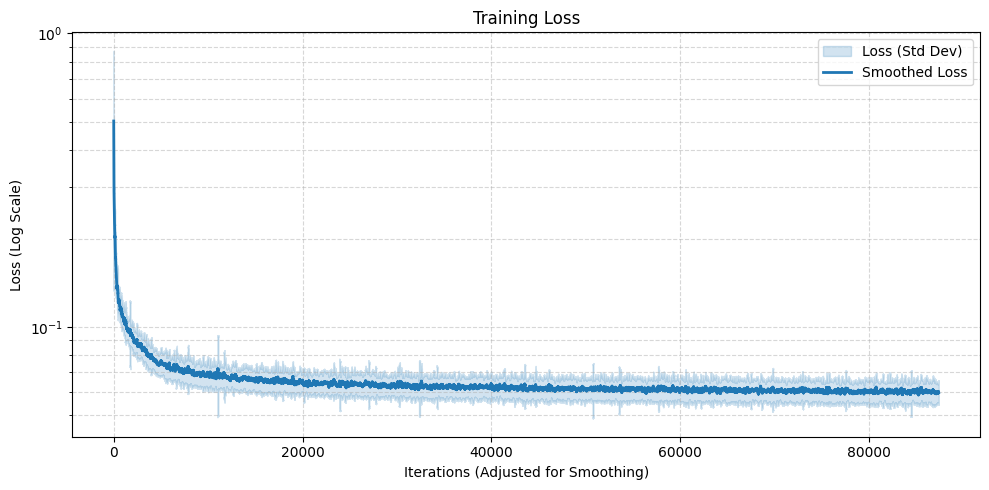

In [57]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss_with_bands(losses, window=100, title="Training Loss", label="Loss"):
    """
    Plots a smoothed loss curve with a shaded variance band on a log scale.
    
    Args:
        losses (list): Raw loss values.
        window (int): Smoothing window size (higher = smoother).
        title (str): Title of the plot.
        label (str): Label for the legend.
    """
    # Convert to array and handle potential zeros for log scale
    data = np.array(losses)
    data = np.clip(data, 1e-10, None) 
    
    # Calculate Moving Average (Solid Line)
    # Using 'valid' means the result is shorter by (window - 1)
    smooth_mean = np.convolve(data, np.ones(window)/window, mode='valid')
    
    # Calculate Rolling Standard Deviation (The Band)
    # We match the 'valid' length of the mean
    smooth_std = np.array([
        np.std(data[i : i + window]) 
        for i in range(len(data) - window + 1)
    ])
    
    epochs = np.arange(len(smooth_mean))

    # Plotting
    plt.figure(figsize=(10, 5))
    
    # The Band
    plt.fill_between(epochs, 
                     smooth_mean - smooth_std, 
                     smooth_mean + smooth_std, 
                     color='tab:blue', alpha=0.2, label=f'{label} (Std Dev)')
    
    # The Solid Line
    plt.plot(epochs, smooth_mean, color='tab:blue', lw=2, label=f'Smoothed {label}')

    # Formatting
    plt.yscale('log')
    plt.title(title)
    plt.xlabel('Iterations (Adjusted for Smoothing)')
    plt.ylabel('Loss (Log Scale)')
    plt.grid(True, which="both", linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss_with_bands(losses)

# Sampling Images with Euler

In [22]:
import matplotlib.pyplot as plt

def view_img(img_tensor):
    mean=[0.5, 0.5, 0.5]
    std=[0.5, 0.5, 0.5]
    
    mean = torch.tensor(mean).reshape(3, 1, 1)
    std = torch.tensor(std).reshape(3, 1, 1)
    
    unnormalized = img_tensor * std + mean  # Tensor still in [C, H, W]
    
    # Display
    plt.imshow(unnormalized.cpu().permute(1, 2, 0).numpy())
    plt.title(img_tensor.shape)
    plt.axis("off")
    plt.show()

In [17]:
@torch.no_grad()
def sample_from_vit(model, z=None, eps=1e-2, sm=False):
    # sample an img
    if z is None:
        if sm:
            z = torch.randn((1, 3, 64, 64)).cuda()
        else:
            z = torch.randn((1, 3, 256, 256)).cuda()
        
    t = torch.zeros((1,)).cuda()
    while t < 0.40:
        x_pred = model(z, t, use_half_stride=True)
        #  v_pred = (x_pred - z) / (1 - t)
        v_pred = (x_pred - z) / torch.clip(1 - t + 1e-8, min=0.05)
        z = (z + eps * v_pred)
        t = t + eps
        
    return x_pred

In [36]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def sample_and_visualize_vit(model, z=None, eps=1e-2, sm=False):
    # 1. Initialization
    if z is None:
        dim = 64 if sm else 256
        z = torch.randn((1, 3, dim, dim)).cuda()
        
    t = torch.zeros((1,)).cuda()
    images = []
    milestones = [0, 0.05, 0.08, 0.1, 0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    next_milestone_idx = 0

    # 2. Iterative Refinement Loop
    while t < 1:
        x_pred = model(z, t, use_half_stride=True)
        v_pred = (x_pred - z) / torch.clip(1 - t + 1e-8, min=0.05) # added epsilon for stability
        z = (z + eps * v_pred)
        
        # Logic for t progression
        t_val = t.item()
                
        t = t + eps
        
        # 3. Capture snapshots every 10%
        if next_milestone_idx < len(milestones) and t_val >= milestones[next_milestone_idx]:
            # Detach, move to CPU, and normalize for plotting
            img_snapshot = x_pred.squeeze().permute(1, 2, 0).cpu().numpy()
            # Basic normalization (adjust based on your model's output range)
            img_snapshot = (img_snapshot - img_snapshot.min()) / (img_snapshot.max() - img_snapshot.min() + 1e-8)
            images.append((round(t_val, 3), img_snapshot))
            next_milestone_idx += 1
            
    # 4. Plotting
    plt.figure(figsize=(20, 4))
    for i, (time_step, img) in enumerate(images):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img)
        plt.title(f"t = {time_step}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return x_pred

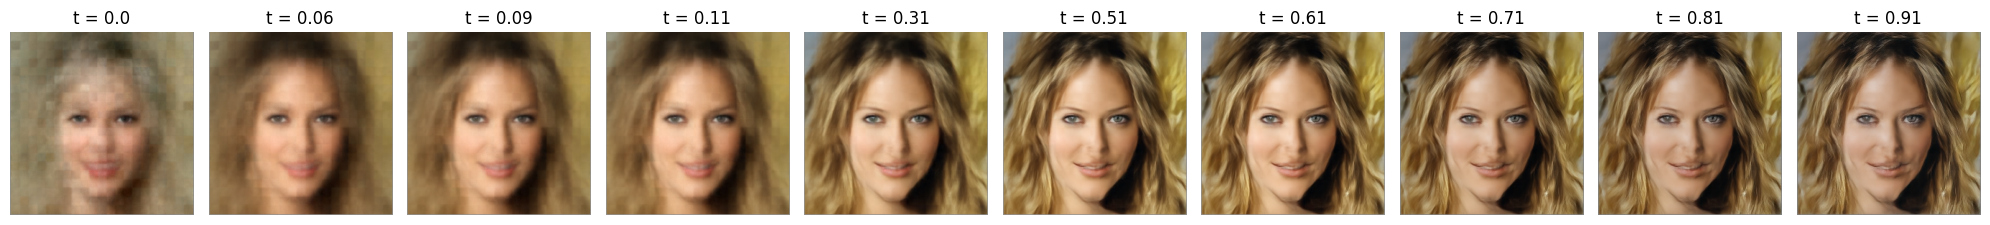

In [48]:
x = sample_and_visualize_vit(vit, eps=1e-2, sm=False)

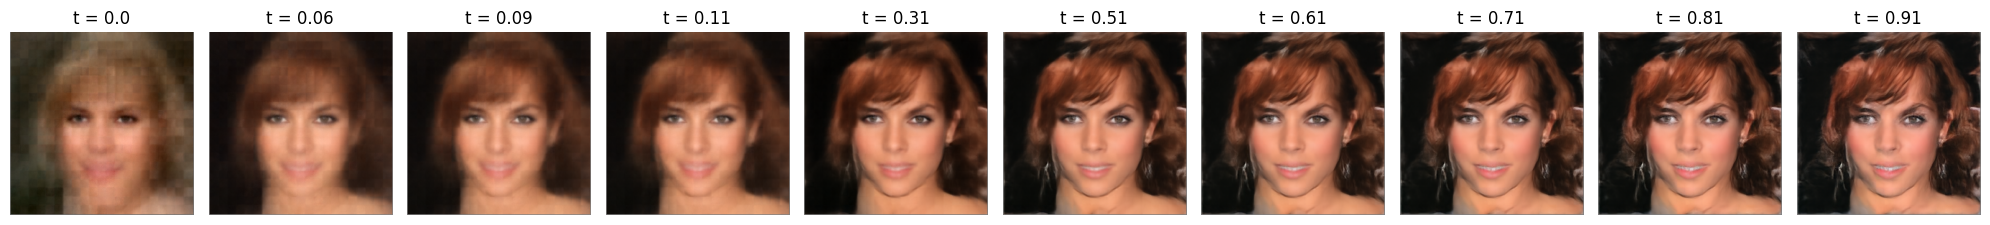

In [41]:
x = sample_and_visualize_vit(vit, eps=1e-2, sm=False)

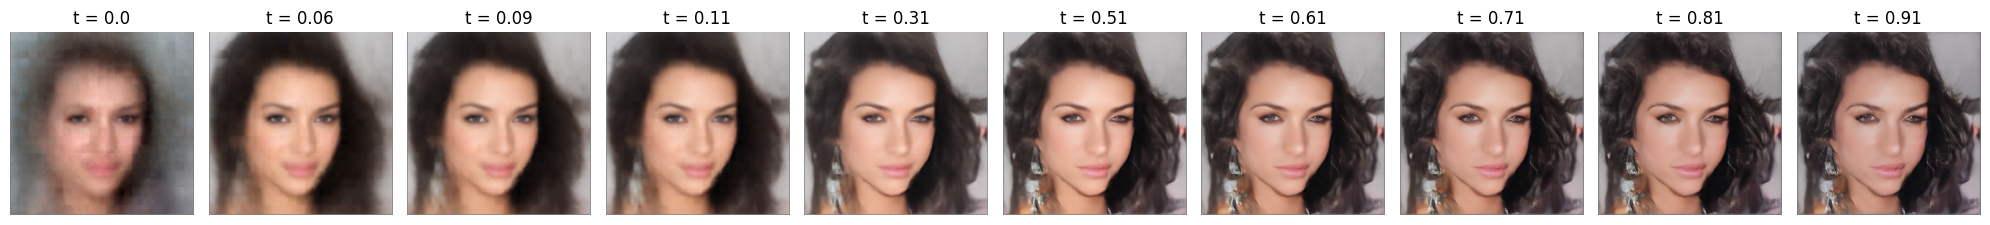

In [38]:
x = sample_and_visualize_vit(vit, eps=1e-2, sm=False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0338158..0.9792316].


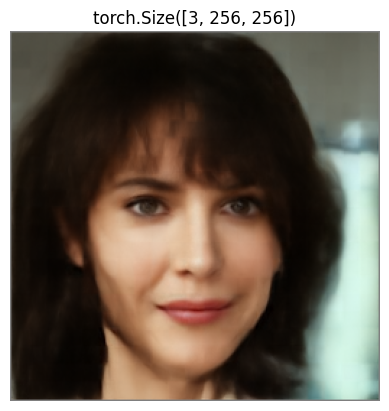

In [82]:
view_img(sample_from_vit(vit)[0].cpu())

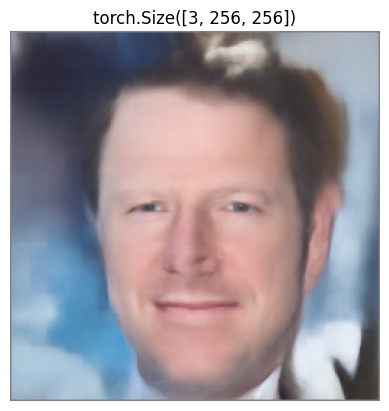

In [69]:
view_img(sample_from_vit(vit)[0].cpu())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.045216262..0.8362883].


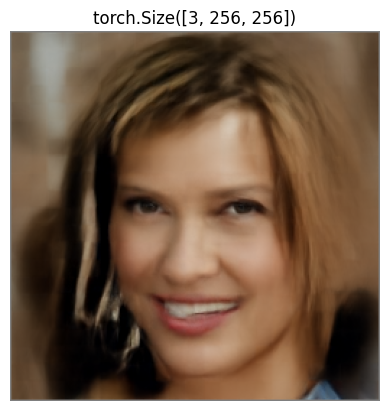

In [28]:
view_img(sample_from_vit(vit)[0].cpu())